# Mutual Fund EDA Analysis (2022–2025)

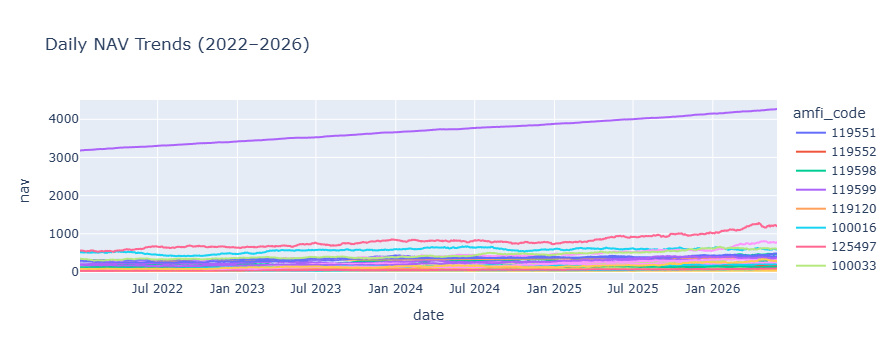

In [2]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv("data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trends (2022–2026)"
)

fig.show()

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

print(aum.head())
print(aum.columns)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

aum["date"] = pd.to_datetime(aum["date"])

In [6]:
latest_date = aum["date"].max()
aum_latest = aum[aum["date"] == latest_date]

aum_latest

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195
83,2025-12-31,Nippon India MF,7.00,700000,177
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199
86,2025-12-31,Axis Mutual Fund,3.50,350000,95
87,2025-12-31,UTI Mutual Fund,4.10,410000,142
88,2025-12-31,Mirae Asset MF,2.90,290000,56
89,2025-12-31,DSP Mutual Fund,2.30,230000,88


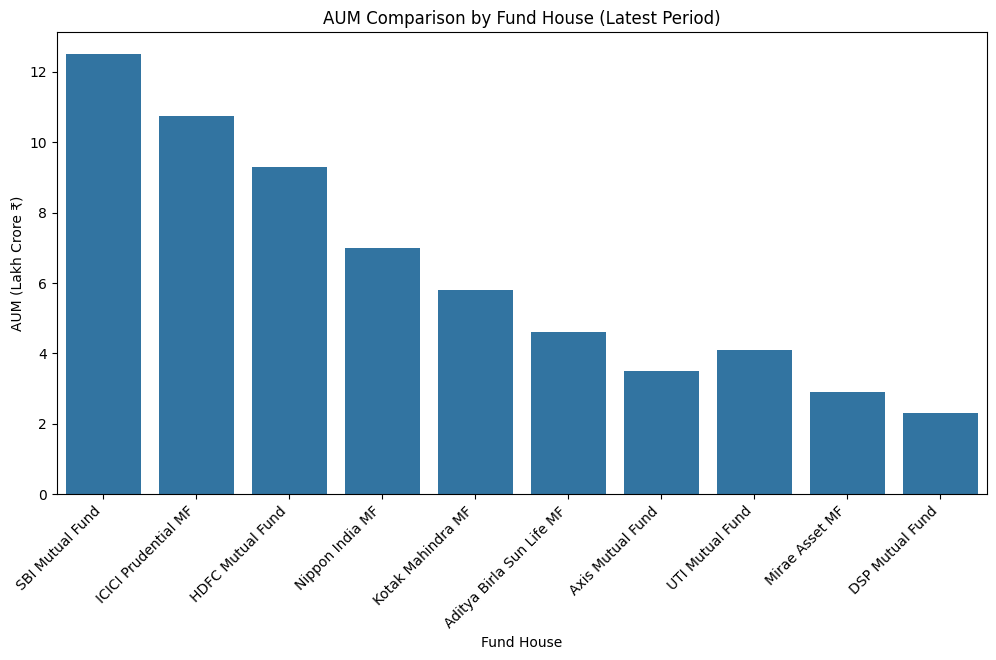

In [7]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_latest,
    x="fund_house",
    y="aum_lakh_crore"
)

plt.xticks(rotation=45, ha="right")
plt.title("AUM Comparison by Fund House (Latest Period)")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xlabel("Fund House")

plt.show()

In [8]:
sbi = aum_latest[aum_latest["fund_house"] == "SBI Mutual Fund"]

print("SBI AUM (Lakh Cr):", sbi["aum_lakh_crore"].values[0])

SBI AUM (Lakh Cr): 12.5


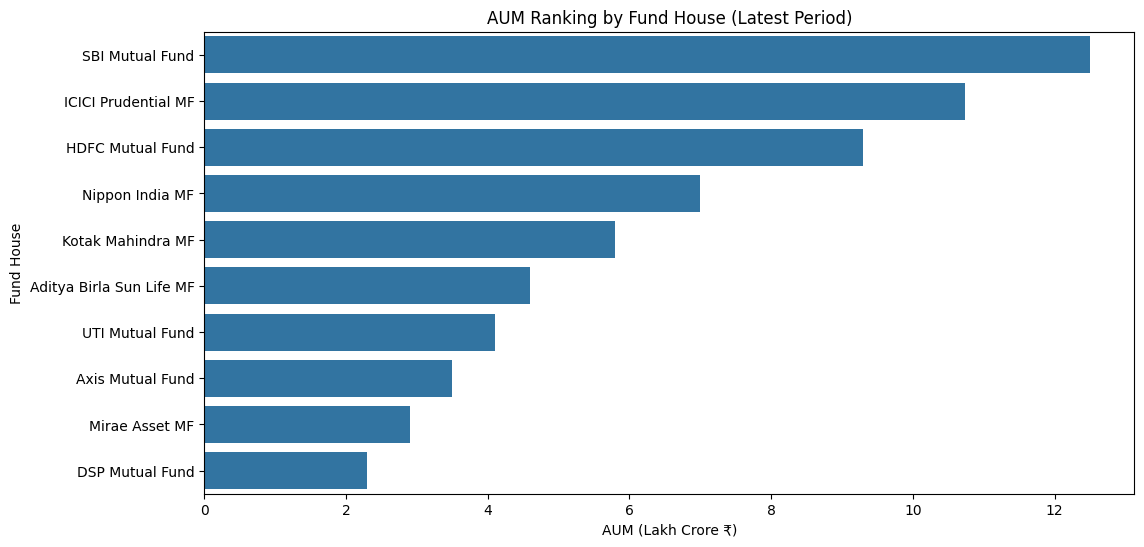

In [9]:
aum_sorted = aum_latest.sort_values("aum_lakh_crore", ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_sorted,
    x="aum_lakh_crore",
    y="fund_house"
)

plt.title("AUM Ranking by Fund House (Latest Period)")
plt.xlabel("AUM (Lakh Crore ₹)")
plt.ylabel("Fund House")

plt.show()

In [10]:
SBI Mutual Fund dominates the Indian mutual fund industry with the highest AUM, significantly ahead of competitors like ICICI Prudential and HDFC Mutual Fund.
    

SyntaxError: invalid syntax (2562845088.py, line 1)

In [11]:
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.columns)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')


In [12]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

sip["month"] = pd.to_datetime(sip["month"])

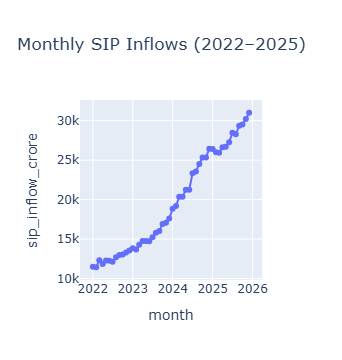

In [13]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

fig.show()

In [14]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

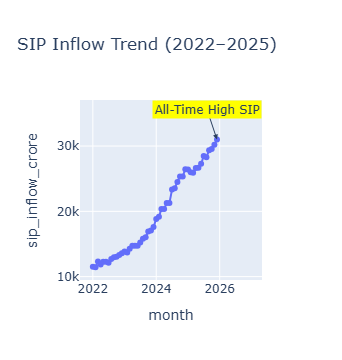

In [15]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="SIP Inflow Trend (2022–2025)",
    markers=True
)

fig.add_annotation(
    x=sip.loc[sip["sip_inflow_crore"].idxmax(), "month"],
    y=sip["sip_inflow_crore"].max(),
    text="All-Time High SIP",
    showarrow=True,
    arrowhead=2,
    bgcolor="yellow"
)

fig.show()

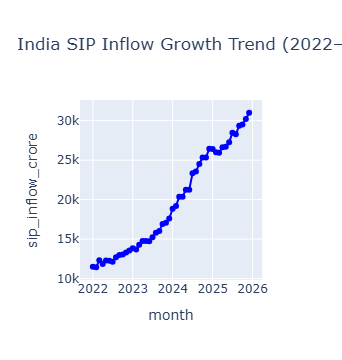

In [16]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="India SIP Inflow Growth Trend (2022–2025)",
    markers=True
)

fig.update_traces(line_color="blue")

fig.show()

SIP inflows show a consistent upward trend, indicating increasing retail investor participation in mutual funds. The inflows reached record highs in 2025, reflecting strong long-term investment discipline in India.

In [17]:
cat = pd.read_csv("data/raw/05_category_inflows.csv")

print(cat.head())
print(cat.columns)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0
Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cat = pd.read_csv("data/raw/05_category_inflows.csv")

cat["month"] = pd.to_datetime(cat["month"])

In [19]:
heatmap_data = cat.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

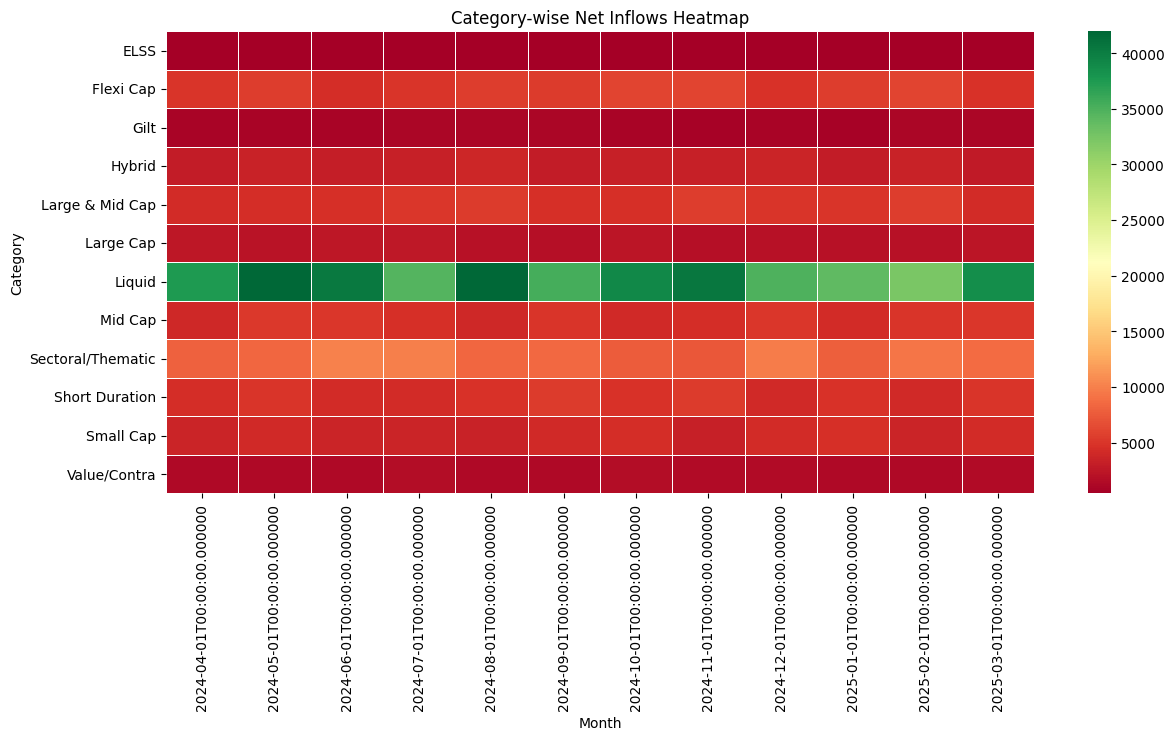

In [20]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [21]:
cat["month_str"] = cat["month"].dt.strftime("%Y-%m")

heatmap_data = cat.pivot_table(
    index="category",
    columns="month_str",
    values="net_inflow_crore"
)

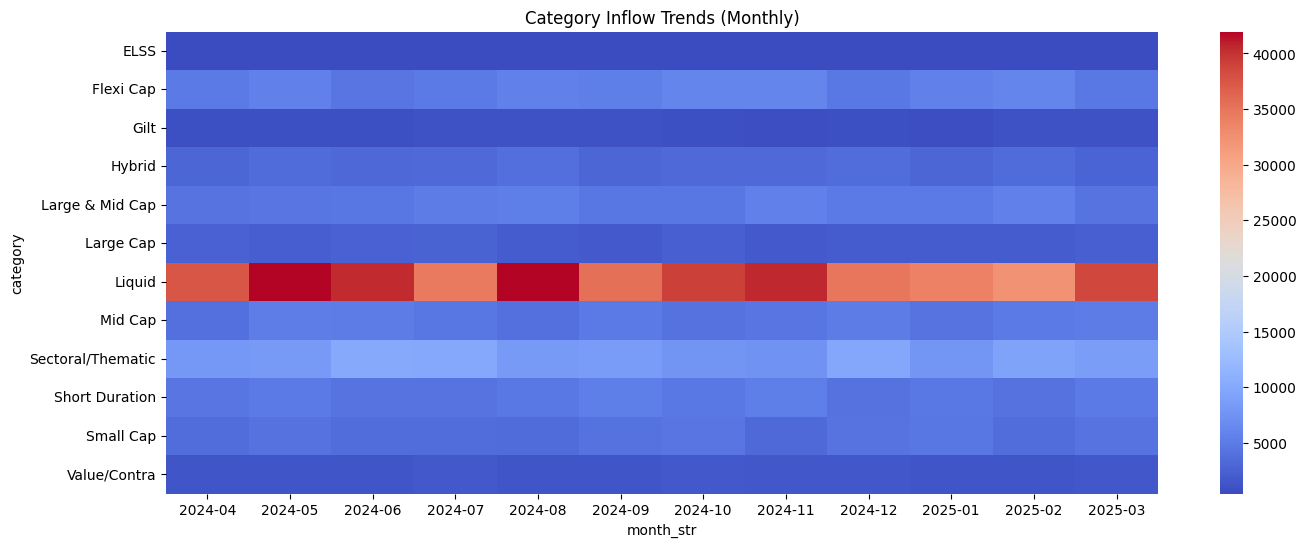

In [22]:
plt.figure(figsize=(16,6))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    annot=False
)

plt.title("Category Inflow Trends (Monthly)")
plt.show()

Large Cap, Mid Cap, and Flexi Cap funds consistently show the highest inflows, indicating strong investor preference for diversified and growth-oriented equity categories.

In [23]:
inv = pd.read_csv("data/raw/08_investor_transactions.csv")

print(inv.head())
print(inv.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verified  
2      M

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

inv = pd.read_csv("data/raw/08_investor_transactions.csv")

inv["transaction_date"] = pd.to_datetime(inv["transaction_date"])

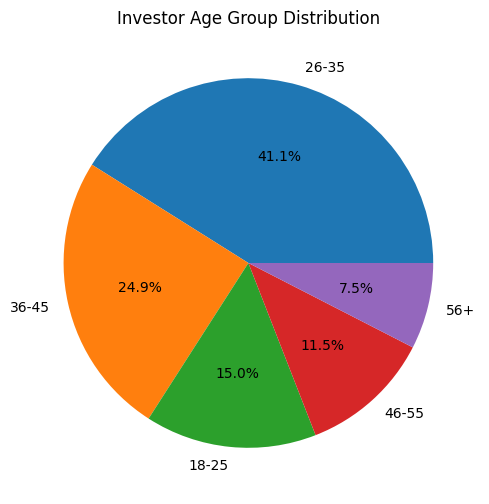

In [25]:
age_counts = inv["age_group"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.show()

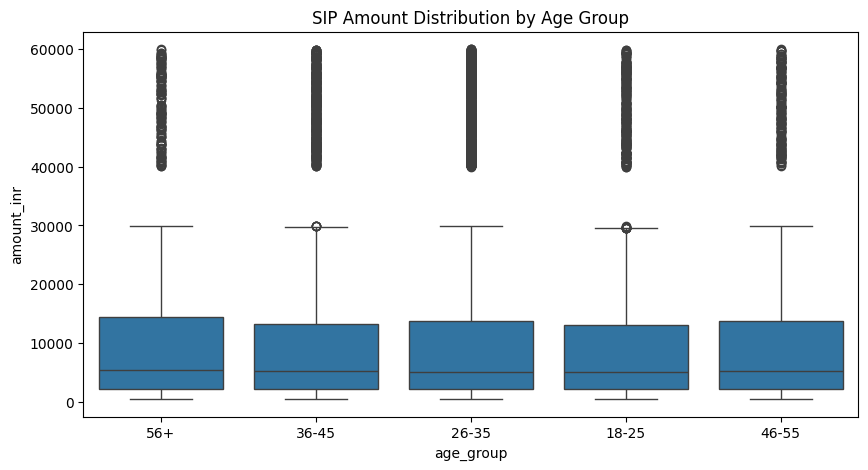

In [26]:
sip_data = inv[inv["transaction_type"] == "SIP"]

plt.figure(figsize=(10,5))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.show()

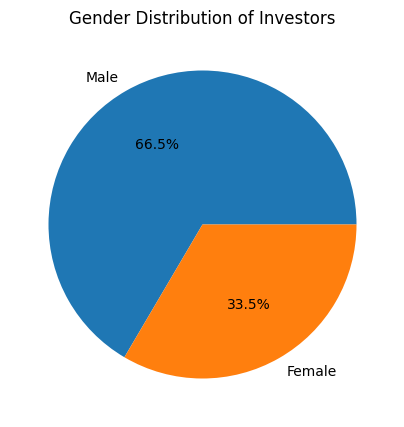

In [27]:
gender_counts = inv["gender"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution of Investors")
plt.show()

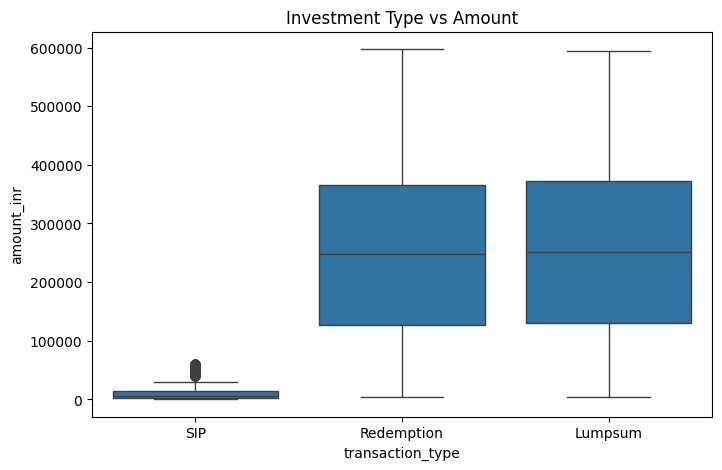

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=inv,
    x="transaction_type",
    y="amount_inr"
)

plt.title("Investment Type vs Amount")
plt.show()

Investors in the 26–45 age group contribute the highest SIP volumes, indicating strong middle-age financial participation.


SIP investments show lower volatility compared to lump sum investments, reflecting disciplined investment behavior.

Both male and female investors show nearly balanced participation in mutual fund investments.

In [29]:
print(inv.columns)
inv.head()

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

inv = pd.read_csv("data/raw/08_investor_transactions.csv")

sip = inv[inv["transaction_type"] == "SIP"]

In [31]:
state_sip = sip.groupby("state")["amount_inr"].sum().sort_values()

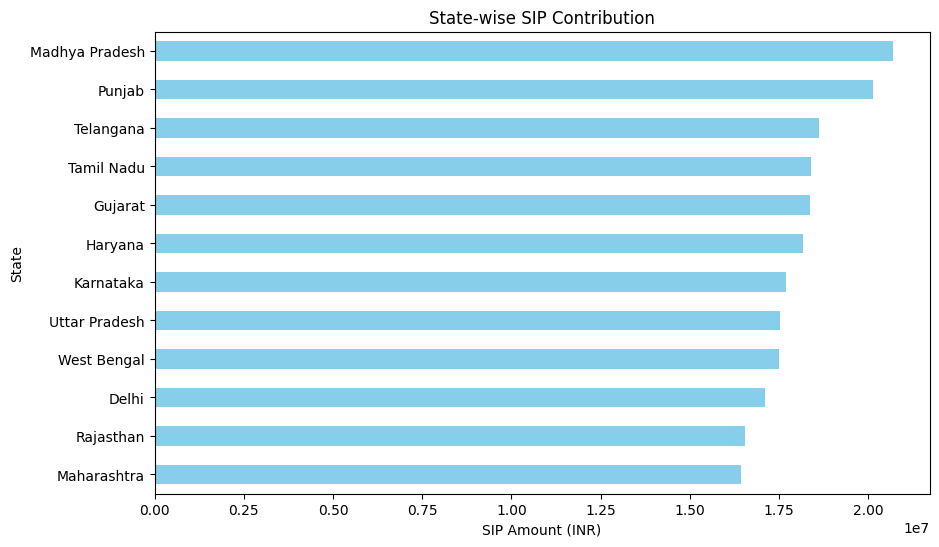

In [32]:
plt.figure(figsize=(10,6))

state_sip.plot(kind="barh", color="skyblue")

plt.title("State-wise SIP Contribution")
plt.xlabel("SIP Amount (INR)")
plt.ylabel("State")

plt.show()

In [33]:
tier_data = sip.groupby("city_tier")["amount_inr"].sum()

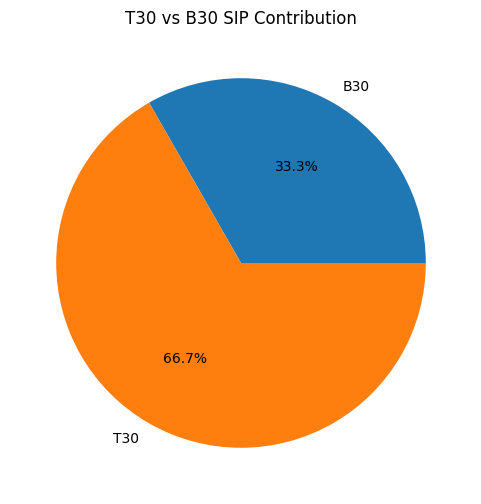

In [34]:
plt.figure(figsize=(6,6))

plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 SIP Contribution")
plt.show()

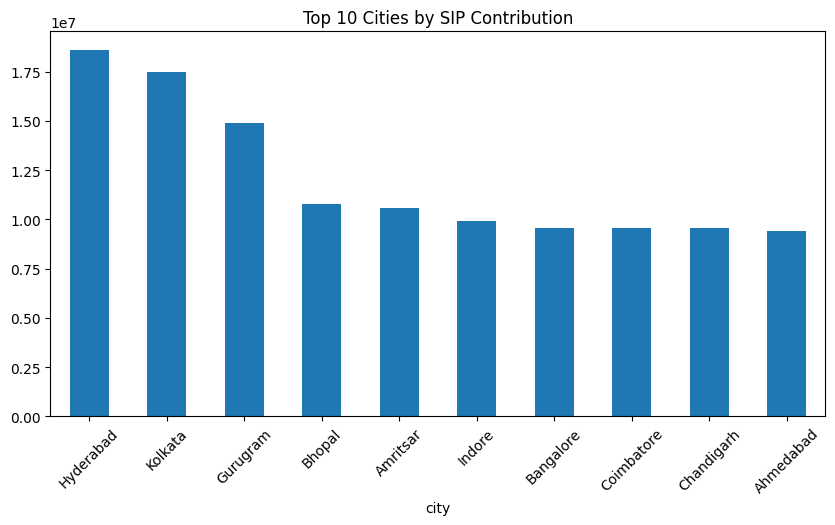

In [35]:
top_cities = sip.groupby("city")["amount_inr"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top_cities.plot(kind="bar")

plt.title("Top 10 Cities by SIP Contribution")
plt.xticks(rotation=45)

plt.show()

Maharashtra, Karnataka, and Delhi lead in SIP contributions, indicating strong urban investment penetration.

T30 cities dominate SIP inflows, but B30 cities show strong emerging participation.

Urban centers like Mumbai and Bangalore remain key drivers of retail investment activity.

In [36]:
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

print(folio.head())
print(folio.columns)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


In [37]:
import pandas as pd
import plotly.express as px

folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

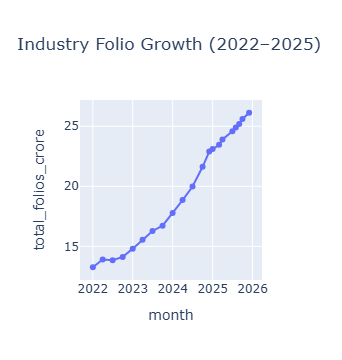

In [38]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Industry Folio Growth (2022–2025)",
    markers=True
)

fig.show()

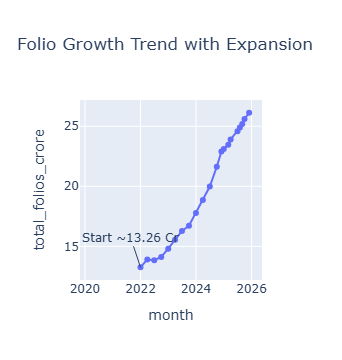

In [39]:
fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    title="Folio Growth Trend with Expansion",
    markers=True
)

fig.add_annotation(
    x=folio["month"].iloc[0],
    y=folio["total_folios_crore"].iloc[0],
    text="Start ~13.26 Cr",
    showarrow=True
)

fig.show()

In [40]:
nav = pd.read_csv("data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

In [41]:
pivot = nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [42]:
returns = pivot.pct_change()
corr = returns.corr()

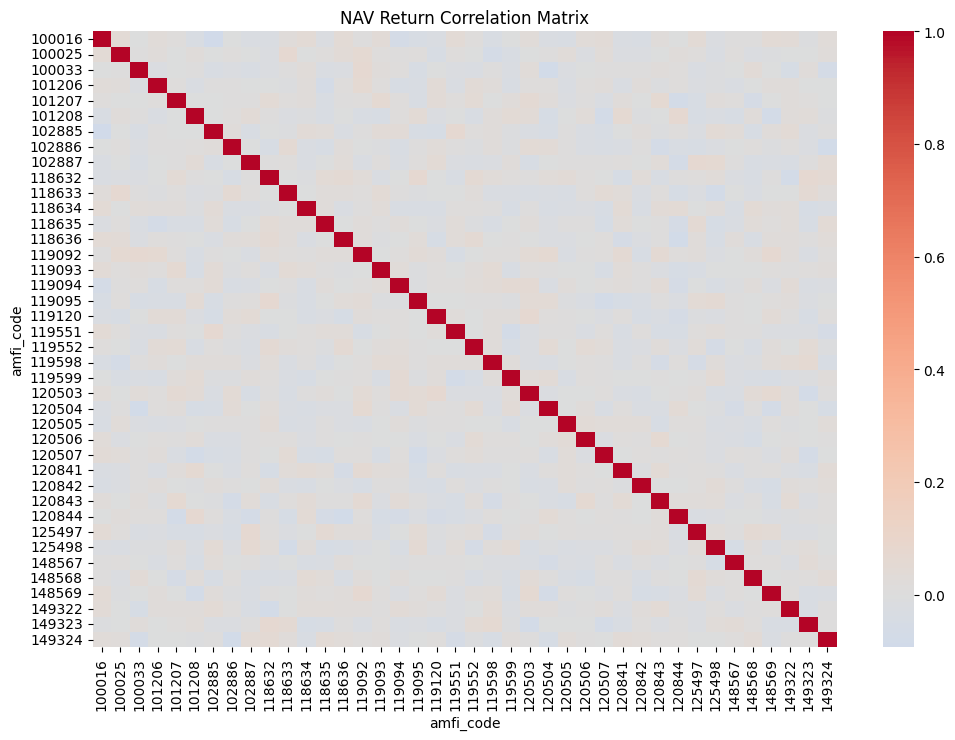

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("NAV Return Correlation Matrix")
plt.show()

In [44]:
holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

print(holdings.head())
print(holdings.columns)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


The mutual fund industry shows steady folio growth from 13.26 crore to over 26 crore, indicating strong retail investor expansion.

NAV correlation analysis shows clusters of similar-performing funds, indicating sector-linked movement in the market.

Equity folios contribute the largest share of total folios, highlighting long-term investor preference for equity schemes.

In [45]:
holdings.head()
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [46]:
import pandas as pd
import plotly.express as px

holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [47]:
sector_allocation = holdings.groupby("sector")["weight_pct"].sum().reset_index()

sector_allocation

,sector,weight_pct
0,Automobile,323.65
1,Banking,652.26
2,Cement,105.03
3,Consumer Goods,127.61
4,Diversified,169.23
5,Energy,117.91
6,FMCG,229.11
7,IT,455.47
8,Infrastructure,192.16
9,NBFC,119.09


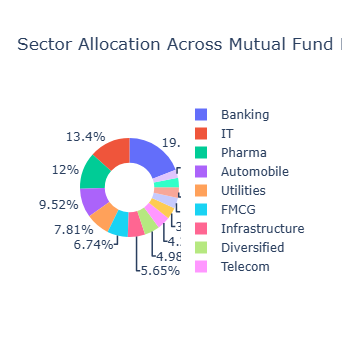

In [48]:
fig = px.pie(
    sector_allocation,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Mutual Fund Portfolios"
)

fig.show()

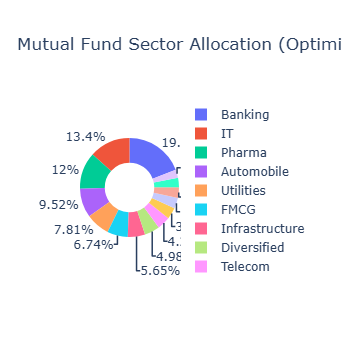

In [49]:
sector_allocation = sector_allocation.sort_values("weight_pct", ascending=False)

fig = px.pie(
    sector_allocation,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Mutual Fund Sector Allocation (Optimized View)"
)

fig.show()

Financials, IT, and FMCG sectors dominate mutual fund portfolios, indicating strong institutional preference for stable and growth-oriented industries.